# Preliminary EDA and Dataset Creation


The notebook is structured as follows:

1. Download and clean intraday data
2. Check data quality and complete trading days
3. Combine SPX, VIX, and SPY into one intraday dataset
4. Prepare intraday variables for feature creation
5. Create one daily modelling row per trading day
6. Convert final-hour returns into target classes
7. Explore final-hour return behaviour through preliminary EDA
8. Prepare the dataset for baseline modelling
9. Fit a simple logistic regression benchmark

# 1. Imports, settings, and data download

This section downloads the first version of the intraday dataset.

For the preliminary EDA, we use:

- `^GSPC` as the SPX index price series
- `^VIX` as a proxy for implied volatility conditions
- `SPY` as a proxy for volume and VWAP, because SPX itself is an index and does not have meaningful trading volume

Yahoo Finance is used for now because it is simple and free. The limitation is that 15-minute intraday data is usually only available for a short recent window, so this is suitable for initial EDA rather than the final dissertation dataset.

In [ ]:
# Basic libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from statsmodels.tsa.stattools import adfuller
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Tickers
TICKER_SPX = "^GSPC"
TICKER_VIX = "^VIX"
TICKER_SPY = "SPY"

# Yahoo Finance settings 60 days of 15-minute data is the maximum allowed.
PERIOD = "60d"
INTERVAL = "15m"

# Market session settings for the New York Stock Exchange (NYSE)
TZ = "America/New_York"
SESSION_START = "09:30"
SESSION_END = "16:00"

# We enter at 3:00pm using the latest fully available 15-minute bar.
# In 15-minute Yahoo data, the 14:45 bar represents 14:45 to 15:00.
ENTRY_BAR_TIME = "14:45:00"

# The 15:45 bar represents 15:45 to 16:00, so its close is used as the final close.
CLOSE_BAR_TIME = "15:45:00"

RANDOM_STATE = 42

## Download intraday data

We now download SPX, VIX, and SPY separately.

At this early EDA stage, the code is intentionally kept simple. More robust error handling can be added later when the data pipeline becomes more permanent.

In [2]:
spx_raw = yf.download(
    TICKER_SPX,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=True,
    progress=False
)

vix_raw = yf.download(
    TICKER_VIX,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=True,
    progress=False
)

spy_raw = yf.download(
    TICKER_SPY,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=True,
    progress=False
)

## Basic timestamp and session cleaning

Yahoo returns timestamps in an exchange-aware format. We convert everything to New York time and keep only the regular U.S. trading session from 9:30am to 4:00pm.

In [ ]:
# Yahoo sometimes returns like:
# ('Close', '^GSPC'), ('High', '^GSPC'), etc.
# This keeps only the price field names: Close, High, Low, Open, Volume
# This was done due to errors in later code when trying to access columns like spx_raw['Close'].

spx_raw.columns = spx_raw.columns.get_level_values(0).str.lower()
vix_raw.columns = vix_raw.columns.get_level_values(0).str.lower()
spy_raw.columns = spy_raw.columns.get_level_values(0).str.lower()

# Convert timestamps to New York time
spx_raw.index = spx_raw.index.tz_convert(TZ)
vix_raw.index = vix_raw.index.tz_convert(TZ)
spy_raw.index = spy_raw.index.tz_convert(TZ)

# Keep regular market hours only
spx_raw = spx_raw.between_time(SESSION_START, SESSION_END, inclusive="left")
vix_raw = vix_raw.between_time(SESSION_START, SESSION_END, inclusive="left")
spy_raw = spy_raw.between_time(SESSION_START, SESSION_END, inclusive="left")

# Label the index clearly as datetime for later merging and analysis.
spx_raw.index.name = "datetime"
vix_raw.index.name = "datetime"
spy_raw.index.name = "datetime"

print("SPX:", spx_raw.shape, spx_raw.index.min(), "to", spx_raw.index.max())
print("VIX:", vix_raw.shape, vix_raw.index.min(), "to", vix_raw.index.max())
print("SPY:", spy_raw.shape, spy_raw.index.min(), "to", spy_raw.index.max())

spx_raw.head()

SPX: (1560, 5) 2026-03-10 09:30:00-04:00 to 2026-06-03 15:45:00-04:00
VIX: (1517, 5) 2026-03-12 09:30:00-04:00 to 2026-06-03 15:45:00-04:00
SPY: (1560, 5) 2026-03-10 09:30:00-04:00 to 2026-06-03 15:45:00-04:00


Price,close,high,low,open,volume
datetime,,,,,
2026-03-10 09:30:00-04:00,6784.479980,6798.959961,6770.819824,6796.560059,106043536
2026-03-10 09:45:00-04:00,6771.240234,6786.520020,6767.649902,6784.500000,121561689
2026-03-10 10:00:00-04:00,6766.680176,6780.899902,6759.740234,6771.310059,112076454
2026-03-10 10:15:00-04:00,6787.790039,6791.100098,6760.560059,6766.819824,100000419
2026-03-10 10:30:00-04:00,6811.740234,6813.350098,6787.799805,6787.799805,98142171


# 2. Basic data inspection

Before creating features, we first check the structure and quality of the downloaded data.

This section looks at:

- the number of rows and columns
- missing values
- duplicated timestamps
- basic summary statistics
- whether each trading day has the expected number of 15-minute bars

This helps confirm whether the raw dataset is suitable for feature engineering.

In [5]:
# Check the first few rows of each dataset
display(spx_raw.head())
display(vix_raw.head())
display(spy_raw.head())

Price,close,high,low,open,volume
datetime,,,,,
2026-03-10 09:30:00-04:00,6784.479980,6798.959961,6770.819824,6796.560059,106043536
2026-03-10 09:45:00-04:00,6771.240234,6786.520020,6767.649902,6784.500000,121561689
2026-03-10 10:00:00-04:00,6766.680176,6780.899902,6759.740234,6771.310059,112076454
2026-03-10 10:15:00-04:00,6787.790039,6791.100098,6760.560059,6766.819824,100000419
2026-03-10 10:30:00-04:00,6811.740234,6813.350098,6787.799805,6787.799805,98142171


Price,close,high,low,open,volume
datetime,,,,,
2026-03-12 09:30:00-04:00,26.15,26.430000,25.709999,26.260000,0
2026-03-12 09:45:00-04:00,26.66,26.930000,26.080000,26.180000,0
2026-03-12 10:00:00-04:00,25.73,26.620001,25.730000,26.620001,0
2026-03-12 10:15:00-04:00,26.67,26.670000,25.680000,25.730000,0
2026-03-12 10:30:00-04:00,26.24,26.950001,26.240000,26.719999,0


Price,close,high,low,open,volume
datetime,,,,,
2026-03-10 09:30:00-04:00,677.179993,678.784973,675.830017,677.719971,6831179
2026-03-10 09:45:00-04:00,675.849976,677.530029,675.489990,677.169983,2571910
2026-03-10 10:00:00-04:00,675.530029,677.030029,674.760010,675.830017,2457464
2026-03-10 10:15:00-04:00,677.619995,678.049988,674.820007,675.530029,2223817
2026-03-10 10:30:00-04:00,680.030029,680.250000,677.630005,677.640015,2418368


In [6]:
# Check the shape of each dataset
print("SPX shape:", spx_raw.shape)
print("VIX shape:", vix_raw.shape)
print("SPY shape:", spy_raw.shape)

SPX shape: (1560, 5)
VIX shape: (1517, 5)
SPY shape: (1560, 5)


In [7]:
# Check missing values
print("SPX missing values:")
display(spx_raw.isna().sum())

print("VIX missing values:")
display(vix_raw.isna().sum())

print("SPY missing values:")
display(spy_raw.isna().sum())

SPX missing values:


Price
close     0
high      0
low       0
open      0
volume    0
dtype: int64

VIX missing values:


Price
close     0
high      0
low       0
open      0
volume    0
dtype: int64

SPY missing values:


Price
close     0
high      0
low       0
open      0
volume    0
dtype: int64

In [8]:
# Check duplicated timestamps
print("SPX duplicated timestamps:", spx_raw.index.duplicated().sum())
print("VIX duplicated timestamps:", vix_raw.index.duplicated().sum())
print("SPY duplicated timestamps:", spy_raw.index.duplicated().sum())

SPX duplicated timestamps: 0
VIX duplicated timestamps: 0
SPY duplicated timestamps: 0


In [9]:
# Basic descriptive statistics
display(spx_raw.describe())
display(vix_raw.describe())
display(spy_raw.describe())

Price,close,high,low,open,volume
count,1560.000000,1560.000000,1560.000000,1560.000000,1.560000e+03
mean,7042.004531,7047.873038,7035.807650,7041.768230,9.350371e+07
std,371.084409,369.808242,371.827966,370.807351,5.610479e+07
min,6319.870117,6326.990234,6316.910156,6319.770020,3.930700e+07
25%,6686.959961,6697.917480,6681.504883,6689.662354,6.530675e+07
50%,7120.020020,7124.325195,7114.839844,7119.614990,7.788285e+07
75%,7390.787720,7395.819824,7385.312622,7390.260010,1.012275e+08
max,7616.729980,7620.899902,7615.120117,7617.140137,5.213490e+08


Price,close,high,low,open,volume
count,1517.000000,1517.000000,1517.000000,1517.000000,1517.0
mean,20.406691,20.538484,20.282986,20.411081,0.0
std,4.030487,4.093097,3.954213,4.022684,0.0
min,15.240000,15.280000,15.220000,15.240000,0.0
25%,17.410000,17.480000,17.340000,17.410000,0.0
50%,18.610001,18.709999,18.520000,18.620001,0.0
75%,24.129999,24.340000,24.000000,24.139999,0.0
max,31.469999,31.650000,31.150000,31.420000,0.0


Price,close,high,low,open,volume
count,1560.000000,1560.000000,1560.000000,1560.000000,1.560000e+03
mean,702.138335,702.755088,701.497736,702.118140,2.169275e+06
std,37.161968,37.007717,37.243889,37.127449,1.911294e+06
min,629.580017,630.352478,629.280029,629.585022,3.696650e+05
25%,667.655075,668.807495,667.190002,668.142487,1.032191e+06
50%,709.645020,710.059998,709.055023,709.645020,1.569820e+06
75%,736.965012,737.419983,736.455002,736.890015,2.644810e+06
max,759.960022,760.400024,759.849976,759.980286,2.184004e+07


## Check number of bars per trading day

For 15-minute data between 9:30am and 4:00pm, a normal full trading day should have 26 bars.

This check helps identify incomplete trading days or missing intraday observations.

In [10]:
# Count how many 15-minute bars exist for each trading day
spx_bars_per_day = spx_raw.groupby(spx_raw.index.date).size()
vix_bars_per_day = vix_raw.groupby(vix_raw.index.date).size()
spy_bars_per_day = spy_raw.groupby(spy_raw.index.date).size()

bars_per_day = pd.DataFrame({
    "spx_bars": spx_bars_per_day,
    "vix_bars": vix_bars_per_day,
    "spy_bars": spy_bars_per_day
})

display(bars_per_day.head())
display(bars_per_day.tail())

,spx_bars,vix_bars,spy_bars
2026-03-10,26.0,NaN,26.0
2026-03-11,26.0,NaN,26.0
2026-03-12,26.0,26.0,26.0
2026-03-13,26.0,26.0,26.0
2026-03-16,26.0,26.0,26.0


,spx_bars,vix_bars,spy_bars
2026-05-28,26.0,26.0,26.0
2026-05-29,26.0,26.0,26.0
2026-06-01,26.0,26.0,26.0
2026-06-02,26.0,26.0,26.0
2026-06-03,26.0,26.0,26.0


In [11]:
# Summary of bars per day
display(bars_per_day.describe())

,spx_bars,vix_bars,spy_bars
count,60.0,59.000000,60.0
mean,26.0,25.711864,26.0
std,0.0,2.213211,0.0
min,26.0,9.000000,26.0
25%,26.0,26.000000,26.0
50%,26.0,26.000000,26.0
75%,26.0,26.000000,26.0
max,26.0,26.000000,26.0


In [12]:
# Show days that do not have the expected 26 bars
incomplete_days = bars_per_day[
    (bars_per_day["spx_bars"] != 26) |
    (bars_per_day["vix_bars"] != 26) |
    (bars_per_day["spy_bars"] != 26)
]

display(incomplete_days)

,spx_bars,vix_bars,spy_bars
2026-03-10,26.0,NaN,26.0
2026-03-11,26.0,NaN,26.0
2026-05-25,NaN,9.0,NaN


## Keep only complete trading days

A normal full trading day should have 26 fifteen-minute bars.

For this project, we only keep days where SPX, VIX, and SPY all have the full set of bars. This avoids building features from incomplete sessions or days where one of the required inputs is missing.

In [13]:
# Identify dates where all three datasets have 26 bars
valid_days = bars_per_day[
    (bars_per_day["spx_bars"] == 26) &
    (bars_per_day["vix_bars"] == 26) &
    (bars_per_day["spy_bars"] == 26)
].index

print("Number of valid full trading days:", len(valid_days))
print("First valid day:", valid_days.min())
print("Last valid day:", valid_days.max())

Number of valid full trading days: 58
First valid day: 2026-03-12
Last valid day: 2026-06-03


In [14]:
# Keep only observations from valid full trading days
spx_raw = spx_raw[pd.Index(spx_raw.index.date).isin(valid_days)]
vix_raw = vix_raw[pd.Index(vix_raw.index.date).isin(valid_days)]
spy_raw = spy_raw[pd.Index(spy_raw.index.date).isin(valid_days)]

print("SPX after filtering:", spx_raw.shape)
print("VIX after filtering:", vix_raw.shape)
print("SPY after filtering:", spy_raw.shape)

SPX after filtering: (1508, 5)
VIX after filtering: (1508, 5)
SPY after filtering: (1508, 5)


In [15]:
# Confirm that all remaining days now have 26 bars
check_after_filtering = pd.DataFrame({
    "spx_bars": spx_raw.groupby(spx_raw.index.date).size(),
    "vix_bars": vix_raw.groupby(vix_raw.index.date).size(),
    "spy_bars": spy_raw.groupby(spy_raw.index.date).size()
})

display(check_after_filtering.describe())
display(check_after_filtering.head())
display(check_after_filtering.tail())

,spx_bars,vix_bars,spy_bars
count,58.0,58.0,58.0
mean,26.0,26.0,26.0
std,0.0,0.0,0.0
min,26.0,26.0,26.0
25%,26.0,26.0,26.0
50%,26.0,26.0,26.0
75%,26.0,26.0,26.0
max,26.0,26.0,26.0


,spx_bars,vix_bars,spy_bars
2026-03-12,26,26,26
2026-03-13,26,26,26
2026-03-16,26,26,26
2026-03-17,26,26,26
2026-03-18,26,26,26


,spx_bars,vix_bars,spy_bars
2026-05-28,26,26,26
2026-05-29,26,26,26
2026-06-01,26,26,26
2026-06-02,26,26,26
2026-06-03,26,26,26


# 3. Combine SPX, VIX, and SPY into one intraday dataset

Now that incomplete trading days have been removed, the next step is to combine the three data sources into one intraday dataframe.

We use:

- SPX prices as the main prediction asset
- VIX close as the implied volatility proxy
- SPY volume and VWAP-style calculations as liquidity/participation proxies

The columns are renamed clearly so it is always obvious which market each variable comes from.

In [18]:
# Keep only the columns needed from each dataset
spx = spx_raw[["open", "high", "low", "close", "volume"]].copy()
vix = vix_raw[["open", "high", "low", "close", "volume"]].copy()
spy = spy_raw[["open", "high", "low", "close", "volume"]].copy()

In [19]:
# Rename columns so the source is clear after merging
spx.columns = [f"spx_{col}" for col in spx.columns]
vix.columns = [f"vix_{col}" for col in vix.columns]
spy.columns = [f"spy_{col}" for col in spy.columns]

In [20]:
# Combine all three datasets using the datetime index
intraday = pd.concat([spx, vix, spy], axis=1)

print("Combined intraday shape:", intraday.shape)
display(intraday.head())
display(intraday.tail())

Combined intraday shape: (1508, 15)


,spx_open,spx_high,spx_low,spx_close,spx_volume,vix_open,vix_high,vix_low,vix_close,vix_volume,spy_open,spy_high,spy_low,spy_close,spy_volume
datetime,,,,,,,,,,,,,,,
2026-03-12 09:30:00-04:00,6740.879883,6740.879883,6713.000000,6715.339844,217174241,26.260000,26.430000,25.709999,26.15,0,671.159973,671.650024,669.880005,670.289978,7696460
2026-03-12 09:45:00-04:00,6715.069824,6718.640137,6692.700195,6699.000000,132044293,26.180000,26.930000,26.080000,26.66,0,670.280029,670.909973,668.182983,668.869995,5426661
2026-03-12 10:00:00-04:00,6699.169922,6721.950195,6699.169922,6721.000000,117274113,26.620001,26.620001,25.730000,25.73,0,668.869995,671.140015,668.809998,670.969971,4101499
2026-03-12 10:15:00-04:00,6721.020020,6722.819824,6692.490234,6692.660156,105761944,25.730000,26.670000,25.680000,26.67,0,670.989990,671.200012,668.049988,668.059998,3235877
2026-03-12 10:30:00-04:00,6691.979980,6701.000000,6684.770020,6699.890137,110762771,26.719999,26.950001,26.240000,26.24,0,668.059998,669.119995,667.299988,668.955017,3773295


,spx_open,spx_high,spx_low,spx_close,spx_volume,vix_open,vix_high,vix_low,vix_close,vix_volume,spy_open,spy_high,spy_low,spy_close,spy_volume
datetime,,,,,,,,,,,,,,,
2026-06-03 14:45:00-04:00,7572.910156,7574.879883,7570.660156,7572.049805,69266000,16.049999,16.08,16.030001,16.059999,0,755.739990,755.890015,755.489990,755.583008,2611247
2026-06-03 15:00:00-04:00,7571.959961,7571.959961,7563.419922,7566.200195,79448000,16.049999,16.17,16.049999,16.139999,0,755.585022,755.590027,754.710022,755.039978,1006054
2026-06-03 15:15:00-04:00,7566.399902,7570.180176,7561.950195,7564.379883,99024000,16.139999,16.18,16.080000,16.150000,0,755.025024,755.440002,754.609985,754.830017,1533375
2026-06-03 15:30:00-04:00,7564.430176,7570.609863,7562.339844,7568.850098,127946000,16.150000,16.18,15.960000,15.970000,0,754.830017,755.479980,754.619995,755.280029,1801352
2026-06-03 15:45:00-04:00,7568.819824,7570.259766,7553.649902,7556.819824,399147000,15.990000,16.08,15.970000,16.049999,0,755.289978,755.440002,753.900024,754.190002,9895723


## Check the merged dataset

After merging, we check for missing values again. Since we already filtered for complete trading days, there should be no missing values.

In [ ]:
# Check missing values after merging just incase something went wrong
display(intraday.isna().sum())

spx_open      0
spx_high      0
spx_low       0
spx_close     0
spx_volume    0
vix_open      0
vix_high      0
vix_low       0
vix_close     0
vix_volume    0
spy_open      0
spy_high      0
spy_low       0
spy_close     0
spy_volume    0
dtype: int64

In [22]:
# Basic descriptive statistics for the combined dataset
display(intraday.describe())

,spx_open,spx_high,spx_low,spx_close,spx_volume,vix_open,vix_high,vix_low,vix_close,vix_volume,spy_open,spy_high,spy_low,spy_close,spy_volume
count,1508.000000,1508.000000,1508.000000,1508.000000,1.508000e+03,1508.000000,1508.000000,1508.000000,1508.000000,1508.0,1508.000000,1508.000000,1508.000000,1508.000000,1.508000e+03
mean,7050.485536,7056.543381,7044.617019,7050.749939,9.354701e+07,20.433554,20.561631,20.304867,20.429151,0.0,702.960196,703.590061,702.349047,702.982352,2.154123e+06
std,374.083148,373.091202,375.066015,374.347424,5.632636e+07,4.024107,4.094278,3.955808,4.031965,0.0,37.476625,37.358661,37.589782,37.510660,1.926319e+06
min,6319.770020,6326.990234,6316.910156,6319.870117,3.930700e+07,15.240000,15.280000,15.220000,15.240000,0.0,629.585022,630.352478,629.280029,629.580017,3.696650e+05
25%,6679.797363,6683.914917,6673.150146,6679.545044,6.523550e+07,17.427500,17.490000,17.357501,17.430000,0.0,667.130005,667.551270,666.360016,667.013535,1.017415e+06
50%,7123.525146,7128.125000,7117.839844,7123.650146,7.774050e+07,18.625000,18.724999,18.530001,18.620001,0.0,709.979980,710.440002,709.419983,709.989990,1.519591e+06
75%,7393.607422,7398.284912,7389.522461,7394.837524,1.013919e+08,24.165000,24.370001,24.020000,24.170000,0.0,737.169983,737.767502,736.795761,737.296265,2.638247e+06
max,7617.140137,7620.899902,7615.120117,7616.729980,5.213490e+08,31.420000,31.650000,31.150000,31.469999,0.0,759.980286,760.400024,759.849976,759.960022,2.184004e+07


## Add simple intraday return columns

Before creating the final daily modelling dataset, we add basic return columns.

These returns will be used later to create momentum, volatility, and target variables.

In [ ]:
# SPX 15-minute return
intraday["spx_return_15m"] = intraday["spx_close"].pct_change()

# VIX 15-minute change
intraday["vix_change_15m"] = intraday["vix_close"].pct_change()

# SPY 15-minute return
intraday["spy_return_15m"] = intraday["spy_close"].pct_change()

display(intraday.head())

,spx_open,spx_high,spx_low,spx_close,spx_volume,vix_open,vix_high,vix_low,vix_close,vix_volume,spy_open,spy_high,spy_low,spy_close,spy_volume,spx_return_15m,vix_change_15m,spy_return_15m
datetime,,,,,,,,,,,,,,,,,,
2026-03-12 09:30:00-04:00,6740.879883,6740.879883,6713.000000,6715.339844,217174241,26.260000,26.430000,25.709999,26.15,0,671.159973,671.650024,669.880005,670.289978,7696460,NaN,NaN,NaN
2026-03-12 09:45:00-04:00,6715.069824,6718.640137,6692.700195,6699.000000,132044293,26.180000,26.930000,26.080000,26.66,0,670.280029,670.909973,668.182983,668.869995,5426661,-0.002433,0.019503,-0.002118
2026-03-12 10:00:00-04:00,6699.169922,6721.950195,6699.169922,6721.000000,117274113,26.620001,26.620001,25.730000,25.73,0,668.869995,671.140015,668.809998,670.969971,4101499,0.003284,-0.034884,0.003140
2026-03-12 10:15:00-04:00,6721.020020,6722.819824,6692.490234,6692.660156,105761944,25.730000,26.670000,25.680000,26.67,0,670.989990,671.200012,668.049988,668.059998,3235877,-0.004217,0.036533,-0.004337
2026-03-12 10:30:00-04:00,6691.979980,6701.000000,6684.770020,6699.890137,110762771,26.719999,26.950001,26.240000,26.24,0,668.059998,669.119995,667.299988,668.955017,3773295,0.001080,-0.016123,0.001340


It looks like the return numbers are very small, but that is standard for high-frequency intraday financial statistics. As an example, an SPX return of -0.002433 means that the price went down by about -0.2433% in 15 minutes. In this case, it is about -24.33 dollars, which is a lot of money in 15 min trade.

In [24]:
# The first row will have missing returns because there is no previous bar
display(intraday.isna().sum())

spx_open          0
spx_high          0
spx_low           0
spx_close         0
spx_volume        0
vix_open          0
vix_high          0
vix_low           0
vix_close         0
vix_volume        0
spy_open          0
spy_high          0
spy_low           0
spy_close         0
spy_volume        0
spx_return_15m    1
vix_change_15m    1
spy_return_15m    1
dtype: int64

In [25]:
intraday = intraday.dropna()

print("Intraday shape after dropping first return row:", intraday.shape)
display(intraday.head())

Intraday shape after dropping first return row: (1507, 18)


,spx_open,spx_high,spx_low,spx_close,spx_volume,vix_open,vix_high,vix_low,vix_close,vix_volume,spy_open,spy_high,spy_low,spy_close,spy_volume,spx_return_15m,vix_change_15m,spy_return_15m
datetime,,,,,,,,,,,,,,,,,,
2026-03-12 09:45:00-04:00,6715.069824,6718.640137,6692.700195,6699.000000,132044293,26.180000,26.930000,26.08,26.66,0,670.280029,670.909973,668.182983,668.869995,5426661,-0.002433,0.019503,-0.002118
2026-03-12 10:00:00-04:00,6699.169922,6721.950195,6699.169922,6721.000000,117274113,26.620001,26.620001,25.73,25.73,0,668.869995,671.140015,668.809998,670.969971,4101499,0.003284,-0.034884,0.003140
2026-03-12 10:15:00-04:00,6721.020020,6722.819824,6692.490234,6692.660156,105761944,25.730000,26.670000,25.68,26.67,0,670.989990,671.200012,668.049988,668.059998,3235877,-0.004217,0.036533,-0.004337
2026-03-12 10:30:00-04:00,6691.979980,6701.000000,6684.770020,6699.890137,110762771,26.719999,26.950001,26.24,26.24,0,668.059998,669.119995,667.299988,668.955017,3773295,0.001080,-0.016123,0.001340
2026-03-12 10:45:00-04:00,6700.169922,6715.209961,6692.009766,6695.640137,111184058,26.260000,26.590000,25.52,26.48,0,668.929993,670.549988,668.080017,668.500000,4076837,-0.000634,0.009146,-0.000680


# 4. Prepare intraday variables for feature creation

Before creating one modelling row per trading day, we add a few useful intraday columns.

These columns are still at the 15-minute bar level. They will later be aggregated into daily features measured at the 3:00pm decision point.

We add:

- SPX 15-minute returns
- SPX 15-minute log returns
- VIX 15-minute returns
- SPY 15-minute returns
- SPY VWAP
- SPY cumulative volume
- date and time columns

In [1]:
# Add date and time columns
intraday["date"] = intraday.index.date
intraday["time"] = intraday.index.time

# SPX returns
intraday["spx_return_15m"] = intraday["spx_close"].pct_change()
intraday["spx_logret_15m"] = np.log(intraday["spx_close"]).diff()

# VIX returns
intraday["vix_return_15m"] = intraday["vix_close"].pct_change()
intraday["vix_logret_15m"] = np.log(intraday["vix_close"]).diff()

# SPY returns
intraday["spy_return_15m"] = intraday["spy_close"].pct_change()
intraday["spy_logret_15m"] = np.log(intraday["spy_close"]).diff()

NameError: name 'intraday' is not defined

The code also figures out log returns which as shown by literature review is often used in financial time-series analysis because they show the returns that keep adding up between two price readings.

## SPY VWAP and cumulative volume

SPX is an index, so its volume is not very useful for trading participation.

Instead, we use SPY volume as a proxy for market participation and liquidity.

VWAP is calculated using SPY because SPY has meaningful traded volume.

In [ ]:
# Typical price is a simple approximation of the average traded price in each bar
intraday["spy_typical_price"] = (
    intraday["spy_high"] + intraday["spy_low"] + intraday["spy_close"]
) / 3

# Dollar volume proxy for each 15-minute bar
intraday["spy_price_x_volume"] = (
    intraday["spy_typical_price"] * intraday["spy_volume"]
)

# Cumulative volume within each trading day
intraday["spy_cum_volume"] = (
    intraday.groupby("date")["spy_volume"].cumsum()
)

# Cumulative price-volume within each trading day
intraday["spy_cum_price_x_volume"] = (
    intraday.groupby("date")["spy_price_x_volume"].cumsum()
)

# VWAP up to each point in the trading day
intraday["spy_vwap"] = (
    intraday["spy_cum_price_x_volume"] / intraday["spy_cum_volume"]
)

## Check prepared intraday dataset

The dataset now contains both raw OHLCV columns and simple intraday variables needed for feature engineering.

In [ ]:
print("Prepared intraday shape:", intraday.shape)
display(intraday.head())
display(intraday.tail())

Prepared intraday shape: (1507, 29)


,spx_open,spx_high,spx_low,spx_close,spx_volume,vix_open,vix_high,vix_low,vix_close,vix_volume,...,time,spx_logret_15m,vix_return_15m,vix_logret_15m,spy_logret_15m,spy_typical_price,spy_price_x_volume,spy_cum_volume,spy_cum_price_x_volume,spy_vwap
datetime,,,,,,,,,,,,,,,,,,,,,
2026-03-12 09:45:00-04:00,6715.069824,6718.640137,6692.700195,6699.000000,132044293,26.180000,26.930000,26.08,26.66,0,...,09:45:00,NaN,NaN,NaN,NaN,669.320984,3.632178e+09,5426661,3.632178e+09,669.320984
2026-03-12 10:00:00-04:00,6699.169922,6721.950195,6699.169922,6721.000000,117274113,26.620001,26.620001,25.73,25.73,0,...,10:00:00,0.003279,-0.034884,-0.035507,0.003135,670.306661,2.749262e+09,9528160,6.381440e+09,669.745279
2026-03-12 10:15:00-04:00,6721.020020,6722.819824,6692.490234,6692.660156,105761944,25.730000,26.670000,25.68,26.67,0,...,10:15:00,-0.004226,0.036533,0.035882,-0.004346,669.103333,2.165136e+09,12764037,8.546576e+09,669.582536
2026-03-12 10:30:00-04:00,6691.979980,6701.000000,6684.770020,6699.890137,110762771,26.719999,26.950001,26.24,26.24,0,...,10:30:00,0.001080,-0.016123,-0.016254,0.001339,668.458333,2.522290e+09,16537332,1.106887e+10,669.326029
2026-03-12 10:45:00-04:00,6700.169922,6715.209961,6692.009766,6695.640137,111184058,26.260000,26.590000,25.52,26.48,0,...,10:45:00,-0.000635,0.009146,0.009105,-0.000680,669.043335,2.727581e+09,20614169,1.379645e+10,669.270121


,spx_open,spx_high,spx_low,spx_close,spx_volume,vix_open,vix_high,vix_low,vix_close,vix_volume,...,time,spx_logret_15m,vix_return_15m,vix_logret_15m,spy_logret_15m,spy_typical_price,spy_price_x_volume,spy_cum_volume,spy_cum_price_x_volume,spy_vwap
datetime,,,,,,,,,,,,,,,,,,,,,
2026-06-03 14:45:00-04:00,7572.910156,7574.879883,7570.660156,7572.049805,69266000,16.049999,16.08,16.030001,16.059999,0,...,14:45:00,-0.000131,0.000623,0.000623,-0.000155,755.654338,1.973200e+09,28297719,2.138459e+10,755.700133
2026-06-03 15:00:00-04:00,7571.959961,7571.959961,7563.419922,7566.200195,79448000,16.049999,16.17,16.049999,16.139999,0,...,15:00:00,-0.000773,0.004981,0.004969,-0.000719,755.113342,7.596848e+08,29303773,2.214427e+10,755.679987
2026-06-03 15:15:00-04:00,7566.399902,7570.180176,7561.950195,7564.379883,99024000,16.139999,16.18,16.080000,16.150000,0,...,15:15:00,-0.000241,0.000620,0.000619,-0.000278,754.960002,1.157637e+09,30837148,2.330191e+10,755.644186
2026-06-03 15:30:00-04:00,7564.430176,7570.609863,7562.339844,7568.850098,127946000,16.150000,16.18,15.960000,15.970000,0,...,15:30:00,0.000591,-0.011145,-0.011208,0.000596,755.126668,1.360249e+09,32638500,2.466216e+10,755.615624
2026-06-03 15:45:00-04:00,7568.819824,7570.259766,7553.649902,7556.819824,399147000,15.990000,16.08,15.970000,16.049999,0,...,15:45:00,-0.001591,0.005009,0.004997,-0.001444,754.510010,7.466422e+09,42534223,3.212858e+10,755.358399


In [ ]:
# Check missing values after adding returns and VWAP
display(intraday.isna().sum())

spx_open                  0
spx_high                  0
spx_low                   0
spx_close                 0
spx_volume                0
vix_open                  0
vix_high                  0
vix_low                   0
vix_close                 0
vix_volume                0
spy_open                  0
spy_high                  0
spy_low                   0
spy_close                 0
spy_volume                0
spx_return_15m            1
vix_change_15m            0
spy_return_15m            1
date                      0
time                      0
spx_logret_15m            1
vix_return_15m            1
vix_logret_15m            1
spy_logret_15m            1
spy_typical_price         0
spy_price_x_volume        0
spy_cum_volume            0
spy_cum_price_x_volume    0
spy_vwap                  0
dtype: int64

# 5. Create daily modelling dataset

The model will not use every 15-minute bar as a separate observation.

Instead, each trading day becomes one row in the modelling dataset.

For each day:

- features are calculated using information available up to 3:00pm
- the prediction target is the SPX return from 3:00pm to 4:00pm

Because Yahoo 15-minute bars are timestamped at the start of each interval:

- the `14:45` bar represents 14:45 to 15:00
- the `15:45` bar represents 15:45 to 16:00

Therefore:

- `14:45` is used as the decision/entry bar
- `15:45` is used as the final close bar

In [30]:
# A full regular trading day should have 26 fifteen-minute bars
expected_bars_per_day = 26

## Create daily features

This function loops through each trading day and calculates one row of features.

The features are grouped into five main categories:

1. Target variable
2. Momentum features
3. Volatility features
4. Price positioning features
5. SPY volume/VWAP and VIX features

The function is still written as a function because this is easier than manually repeating the same calculations for every day.

In [31]:
def make_daily_features(bars):
    rows = []

    # Loop through each trading day
    for session_date, day in bars.groupby("date"):
        day = day.sort_index().copy()

        # Skip incomplete sessions
        if len(day) < expected_bars_per_day:
            continue

        # Select the 3:00pm decision point and the final 4:00pm close proxy
        entry_rows = day[day.index.strftime("%H:%M:%S") == ENTRY_BAR_TIME]
        close_rows = day[day.index.strftime("%H:%M:%S") == CLOSE_BAR_TIME]

        if entry_rows.empty or close_rows.empty:
            continue

        entry = entry_rows.iloc[-1]
        close_bar = close_rows.iloc[-1]

        # Only use information available up to the entry time
        pre = day.loc[:entry.name].copy()

        if len(pre) < 5:
            continue

        # Basic price levels
        day_open = pre["spx_open"].iloc[0]
        entry_price = entry["spx_close"]
        final_close = close_bar["spx_close"]

        session_high_pre = pre["spx_high"].max()
        session_low_pre = pre["spx_low"].min()

        # Returns used for realized volatility
        spx_log_returns = pre["spx_logret_15m"].dropna()

        # True range calculation for ATR-style features
        previous_close = pre["spx_close"].shift(1)

        true_range = pd.concat(
            [
                pre["spx_high"] - pre["spx_low"],
                (pre["spx_high"] - previous_close).abs(),
                (pre["spx_low"] - previous_close).abs()
            ],
            axis=1
        ).max(axis=1)

        # Create one row for this trading day
        row = {
            # Date and prices
            "date": pd.to_datetime(session_date),
            "entry_datetime": entry.name,
            "entry_price": entry_price,
            "final_close": final_close,

            # Target: return from 3:00pm to 4:00pm
            "target_final_hour_return": final_close / entry_price - 1,

            # Momentum features
            "ret_open_to_1500": entry_price / day_open - 1,
            "ret_last_15m": pre["spx_close"].pct_change(1).iloc[-1],
            "ret_last_30m": entry_price / pre["spx_close"].iloc[-3] - 1 if len(pre) >= 3 else np.nan,
            "ret_last_60m": entry_price / pre["spx_close"].iloc[-5] - 1 if len(pre) >= 5 else np.nan,
            "momentum_accel_60m_vs_prior": (
                (entry_price / pre["spx_close"].iloc[-5] - 1)
                - (pre["spx_close"].iloc[-5] / pre["spx_close"].iloc[-9] - 1)
            ) if len(pre) >= 9 else np.nan,

            # Volatility features
            "rv_open_to_1500": np.sqrt(np.sum(spx_log_returns ** 2)) if len(spx_log_returns) else np.nan,
            "realized_vol_60m": spx_log_returns.tail(4).std() * np.sqrt(4) if len(spx_log_returns) >= 4 else np.nan,
            "realized_vol_120m": spx_log_returns.tail(8).std() * np.sqrt(8) if len(spx_log_returns) >= 8 else np.nan,
            "atr_open_to_1500": true_range.mean(),
            "atr_60m": true_range.tail(4).mean() if len(true_range) >= 4 else np.nan,
            "range_open_to_1500_pct": session_high_pre / session_low_pre - 1,
            "range_expansion_ratio": true_range.tail(4).mean() / true_range.mean() if true_range.mean() else np.nan,

            # Price positioning features
            "dist_from_day_high_pct": entry_price / session_high_pre - 1,
            "dist_from_day_low_pct": entry_price / session_low_pre - 1,
            "position_in_day_range": (
                (entry_price - session_low_pre) / (session_high_pre - session_low_pre)
                if session_high_pre != session_low_pre else np.nan
            ),
            "dist_from_open_pct": entry_price / day_open - 1,

            # SPY volume and VWAP features
            "spy_dist_from_vwap_pct": (
                entry["spy_close"] / entry["spy_vwap"] - 1
                if pd.notna(entry["spy_vwap"]) else np.nan
            ),
            "spy_cum_volume_to_1500": entry["spy_cum_volume"],
            "spy_volume_last_60m": pre["spy_volume"].tail(4).sum(),
            "spy_volume_accel_60m_vs_avg": (
                pre["spy_volume"].tail(4).mean() / pre["spy_volume"].mean()
                if pre["spy_volume"].mean() else np.nan
            ),

            # VIX features
            "vix_level_1500": entry["vix_close"],
            "vix_change_open_to_1500": entry["vix_close"] / pre["vix_open"].iloc[0] - 1,
            "vix_ret_last_60m": entry["vix_close"] / pre["vix_close"].iloc[-5] - 1 if len(pre) >= 5 else np.nan,
            "vix_realized_vol_to_1500": np.sqrt(
                np.sum(np.log(pre["vix_close"]).diff().dropna() ** 2)
            ),

            # Calendar feature
            "day_of_week": pd.to_datetime(session_date).dayofweek
        }

        rows.append(row)

    features = pd.DataFrame(rows)
    features = features.sort_values("date").reset_index(drop=True)

    return features

## Linking the Literature Review to Feature Engineering

The feature engineering stage connects the literature review to the practical modelling part of the dissertation. The target variable, `target_final_hour_return`, measures the SPX return from 3:00pm to 4:00pm, which directly matches the dissertation aim of predicting final-hour SPX movement for possible 0DTE options trading decisions.

| Feature group       | Features                                                                                          | Literature link                                                     | Reason for use                                                                          |
| ------------------- | ------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------- | --------------------------------------------------------------------------------------- |
| Target variable     | `target_final_hour_return`                                                                        | Vilkov [10], Bozovic [13]                                           | Measures the final-hour SPX movement that affects 0DTE option outcomes.                 |
| Momentum            | `ret_open_to_1500`, `ret_last_15m`, `ret_last_30m`, `ret_last_60m`, `momentum_accel_60m_vs_prior` | Ferreira and Medeiros [5], Kawaller et al. [3]                      | Tests whether earlier intraday price direction helps predict the final hour.            |
| Realised volatility | `rv_open_to_1500`, `realized_vol_60m`, `realized_vol_120m`                                        | Andersen and Bollerslev [6], Poon and Granger [7], Zhang et al. [4] | Captures how unstable the market has been before 3:00pm.                                |
| Range and ATR       | `atr_open_to_1500`, `atr_60m`, `range_open_to_1500_pct`, `range_expansion_ratio`                  | Kawaller et al. [3], Wilder [17]                                    | Measures intraday price movement using high-low ranges and recent volatility expansion. |
| Price positioning   | `dist_from_day_high_pct`, `dist_from_day_low_pct`, `position_in_day_range`, `dist_from_open_pct`  | Dim et al. [11], Vasquez et al. [12]                                | Shows whether SPX is near the day’s high, low, open, or middle of the trading range.    |
| SPY volume          | `spy_cum_volume_to_1500`, `spy_volume_last_60m`, `spy_volume_accel_60m_vs_avg`                    | Kawaller et al. [3], Hasbrouck [21]                                 | Uses SPY volume as a proxy for S&P 500 market participation.                            |
| VWAP                | `spy_dist_from_vwap_pct`                                                                          | Berkowitz et al. [18], Madhavan [19]                                | Measures whether SPY is trading above or below its volume-weighted average price.       |
| VIX                 | `vix_level_1500`, `vix_change_open_to_1500`, `vix_ret_last_60m`, `vix_realized_vol_to_1500`       | Ferreira and Medeiros [5], Fan et al. [9]                           | Captures market uncertainty and volatility expectations before the final hour.          |
| Calendar            | `day_of_week`                                                                                     | Zhang et al. [4], Smirlock and Starks [20]                          | Tests whether final-hour behaviour changes across weekdays.                             |

### Other Features

Most of the characteristics have been well covered in the literature review, but I will briefly justify the need for ATR, VWAP, SPY proxy variable and day of week. ATR was added as a technical volatility measure is due to the fact that ATR measures the daily average of the absolute value of the intraday moves, VWAP distance was added as a method for measuring the extent of intraday buying or selling pressure (as an indicator I personally utilize on a regular basis while trading futures or options), SPY volume was utilized since SPX is an index therefore SPY is a highly liquid proxy for market participation.


In [32]:
features = make_daily_features(intraday)

print("Daily feature dataset shape:", features.shape)
display(features.head())

Daily feature dataset shape: (57, 30)


,date,entry_datetime,entry_price,final_close,target_final_hour_return,ret_open_to_1500,ret_last_15m,ret_last_30m,ret_last_60m,momentum_accel_60m_vs_prior,...,dist_from_open_pct,spy_dist_from_vwap_pct,spy_cum_volume_to_1500,spy_volume_last_60m,spy_volume_accel_60m_vs_avg,vix_level_1500,vix_change_open_to_1500,vix_ret_last_60m,vix_realized_vol_to_1500,day_of_week
0,2026-03-13,2026-03-13 14:45:00-04:00,6652.129883,6631.879883,-0.003044,-0.003201,-0.000380,0.001334,0.002416,0.003501,...,-0.003201,-0.003041,64635066,7472329,0.635844,26.959999,0.057670,-0.023896,0.065116,4
1,2026-03-16,2026-03-16 14:45:00-04:00,6705.660156,6699.850098,-0.000866,0.004688,-0.000883,-0.000240,0.001299,0.000772,...,0.004688,0.000467,58024423,9481040,0.898686,23.770000,-0.051476,-0.012874,0.058074,0
2,2026-03-17,2026-03-17 14:45:00-04:00,6720.209961,6717.189941,-0.000449,-0.000318,0.000336,0.000192,-0.000914,-0.001999,...,-0.000318,-0.001381,49830735,9019954,0.995565,22.340000,-0.000894,0.004496,0.039803,1
3,2026-03-18,2026-03-18 14:45:00-04:00,6643.350098,6624.379883,-0.002856,-0.008035,-0.002400,-0.004024,-0.004862,-0.004946,...,-0.008035,-0.005223,48290958,10912819,1.242893,24.059999,0.049280,0.033949,0.050765,2
4,2026-03-19,2026-03-19 14:45:00-04:00,6592.549805,6606.200195,0.002071,0.001432,0.002927,0.001854,0.001772,0.001673,...,0.001432,0.001494,71756487,10918728,0.836900,24.490000,-0.100624,-0.019616,0.073078,3


## Check missing values in the feature dataset

Some engineered features can produce missing values if there is not enough prior intraday history.

At this stage, we check missing values before deciding whether to drop or fill anything.

In [33]:
display(features.isna().sum())

date                           0
entry_datetime                 0
entry_price                    0
final_close                    0
target_final_hour_return       0
ret_open_to_1500               0
ret_last_15m                   0
ret_last_30m                   0
ret_last_60m                   0
momentum_accel_60m_vs_prior    0
rv_open_to_1500                0
realized_vol_60m               0
realized_vol_120m              0
atr_open_to_1500               0
atr_60m                        0
range_open_to_1500_pct         0
range_expansion_ratio          0
dist_from_day_high_pct         0
dist_from_day_low_pct          0
position_in_day_range          0
dist_from_open_pct             0
spy_dist_from_vwap_pct         0
spy_cum_volume_to_1500         0
spy_volume_last_60m            0
spy_volume_accel_60m_vs_avg    0
vix_level_1500                 0
vix_change_open_to_1500        0
vix_ret_last_60m               0
vix_realized_vol_to_1500       0
day_of_week                    0
dtype: int

## Preview final-hour returns

The key target variable is `target_final_hour_return`.

This measures the percentage movement in SPX from the 3:00pm decision point to the market close.

In [34]:
display(features[[
    "date",
    "entry_price",
    "final_close",
    "target_final_hour_return"
]].head())

,date,entry_price,final_close,target_final_hour_return
0,2026-03-13,6652.129883,6631.879883,-0.003044
1,2026-03-16,6705.660156,6699.850098,-0.000866
2,2026-03-17,6720.209961,6717.189941,-0.000449
3,2026-03-18,6643.350098,6624.379883,-0.002856
4,2026-03-19,6592.549805,6606.200195,0.002071


# 6. Create target classes

The raw target variable is `target_final_hour_return`, which measures the SPX percentage return from the 3:00pm entry point to the market close.

For the classification model, this continuous return is converted into three classes:

- `Up`: SPX moves meaningfully higher during the final hour
- `Down`: SPX moves meaningfully lower during the final hour
- `Neutral`: SPX remains within a relatively small range

For the preliminary EDA, the thresholds are based on the distribution of historical final-hour returns in this sample.

## Final-hour return distribution

Before choosing class thresholds, we first inspect the distribution of final-hour returns.

This helps avoid choosing arbitrary thresholds too early.

In [35]:
display(features["target_final_hour_return"].describe())

count    57.000000
mean      0.000431
std       0.002334
min      -0.005115
25%      -0.000767
50%       0.000471
75%       0.001511
max       0.008305
Name: target_final_hour_return, dtype: float64

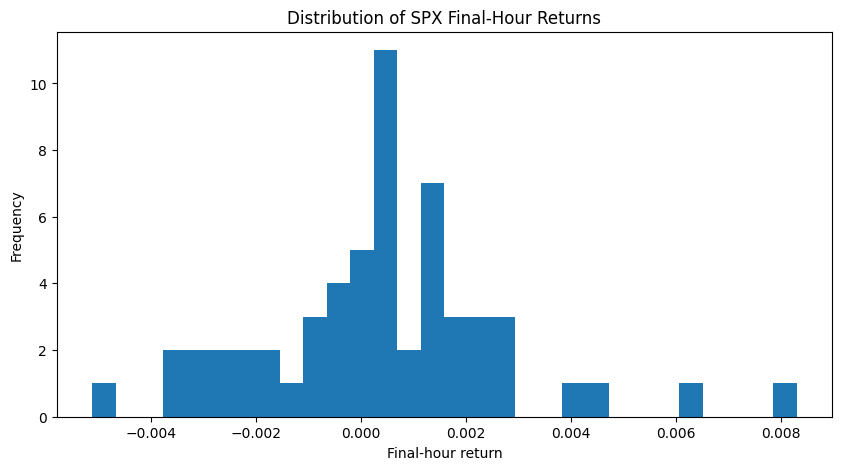

In [36]:
plt.figure(figsize=(10, 5))
plt.hist(features["target_final_hour_return"], bins=30)
plt.title("Distribution of SPX Final-Hour Returns")
plt.xlabel("Final-hour return")
plt.ylabel("Frequency")
plt.show()

Even though these moves may look very small -0.04 % to 0.04% means it could be a 27 point move which is exremely good for EOD options

## Preliminary class thresholds

At this stage, the goal is not to finalise the exact trading threshold.

Instead, we create a reasonable first version of the target classes for EDA and baseline modelling.

Here we use the 33rd and 67th percentiles:

- returns below the 33rd percentile are labelled `Down`
- returns above the 67th percentile are labelled `Up`
- returns between those thresholds are labelled `Neutral`

This creates a roughly balanced three-class problem, which is useful for early model testing.

Later in the dissertation, these thresholds can be changed to represent economically meaningful moves, for example based on transaction costs or minimum option movement required.

In [37]:
lower_threshold = features["target_final_hour_return"].quantile(0.33)
upper_threshold = features["target_final_hour_return"].quantile(0.67)

print("Lower threshold:", lower_threshold)
print("Upper threshold:", upper_threshold)

Lower threshold: -0.000100934052100574
Upper threshold: 0.0011891153138776911


In [38]:
features["target_class"] = np.where(
    features["target_final_hour_return"] <= lower_threshold,
    "Down",
    np.where(
        features["target_final_hour_return"] >= upper_threshold,
        "Up",
        "Neutral"
    )
)

display(features[["date", "target_final_hour_return", "target_class"]].head())

,date,target_final_hour_return,target_class
0,2026-03-13,-0.003044,Down
1,2026-03-16,-0.000866,Down
2,2026-03-17,-0.000449,Down
3,2026-03-18,-0.002856,Down
4,2026-03-19,0.002071,Up


## Key takeaways

Most final-hour SPX returns are clustered around zero, meaning that many sessions have limited movement between 3:00pm and 4:00pm.

There are still several larger up and down moves, which is important for this project because those are the sessions where 0DTE option trades may become more economically meaningful.

Using the 33rd and 67th percentiles gives the following preliminary class thresholds:

- `Down`: final-hour return below -0.01%
- `Neutral`: final-hour return between -0.01% and 0.12%
- `Up`: final-hour return above 0.12%

These thresholds are used only for the first EDA and baseline modelling stage. They are designed to create balanced classes, not to define the final trading strategy.

## Check class balance

The class balance shows how many days fall into each final-hour movement regime.

This is important because a highly imbalanced target would affect model training and evaluation.

In [39]:
class_counts = features["target_class"].value_counts()
display(class_counts)

target_class
Down       19
Up         19
Neutral    19
Name: count, dtype: int64

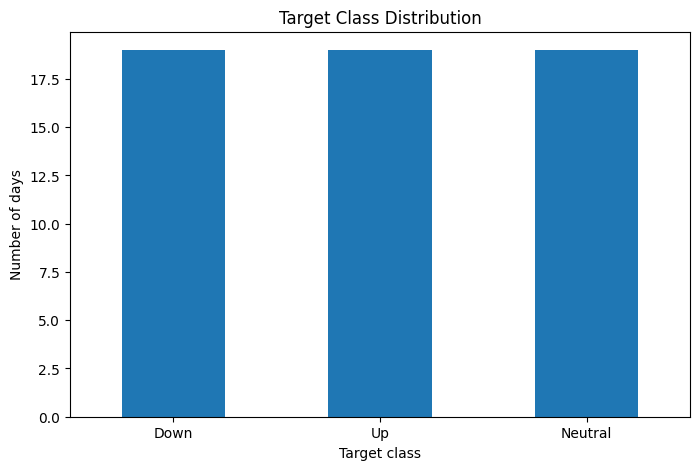

In [40]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Target class")
plt.ylabel("Number of days")
plt.xticks(rotation=0)
plt.show()

## Numeric target labels

Machine learning models usually require numeric labels.

We keep the readable class labels and also create a numeric version:

- `Down` = -1
- `Neutral` = 0
- `Up` = 1

In [42]:
target_mapping = {
    "Down": -1,
    "Neutral": 0,
    "Up": 1
}

features["target"] = features["target_class"].map(target_mapping)

display(features[[
    "date",
    "target_final_hour_return",
    "target_class",
    "target"
]].head())

,date,target_final_hour_return,target_class,target
0,2026-03-13,-0.003044,Down,-1
1,2026-03-16,-0.000866,Down,-1
2,2026-03-17,-0.000449,Down,-1
3,2026-03-18,-0.002856,Down,-1
4,2026-03-19,0.002071,Up,1


In [43]:
print("Feature dataset shape after adding target classes:", features.shape)

display(features[[
    "date",
    "entry_price",
    "final_close",
    "target_final_hour_return",
    "target_class",
    "target"
]].head())

Feature dataset shape after adding target classes: (57, 32)


,date,entry_price,final_close,target_final_hour_return,target_class,target
0,2026-03-13,6652.129883,6631.879883,-0.003044,Down,-1
1,2026-03-16,6705.660156,6699.850098,-0.000866,Down,-1
2,2026-03-17,6720.209961,6717.189941,-0.000449,Down,-1
3,2026-03-18,6643.350098,6624.379883,-0.002856,Down,-1
4,2026-03-19,6592.549805,6606.200195,0.002071,Up,1


# 7. Preliminary EDA on final-hour movement

This section explores the final-hour SPX return and the target classes created in the previous section.

The aim is not to prove predictability yet. Instead, this section helps understand:

- how large final-hour moves usually are
- which days had the largest up and down moves
- whether final-hour movement differs by day of week
- whether simple intraday features appear related to the final-hour target

## Largest final-hour moves

The largest positive and negative final-hour moves are useful to inspect because these are the types of days that may be most relevant for 0DTE options.

A large final-hour move can cause short-dated option premiums to reprice sharply, especially near expiration.

In [46]:
largest_up_moves = features.sort_values("target_final_hour_return", ascending=False).head(10)

display(largest_up_moves[[
    "date",
    "entry_price",
    "final_close",
    "target_final_hour_return",
    "target_class"
]])

,date,entry_price,final_close,target_final_hour_return,target_class
16,2026-04-07,6563.410156,6617.919922,0.008305,Up
45,2026-05-18,7355.350098,7403.100098,0.006492,Up
17,2026-04-08,6753.979980,6783.479980,0.004368,Up
20,2026-04-13,6856.990234,6885.910156,0.004218,Up
41,2026-05-12,7380.589844,7401.629883,0.002851,Up
12,2026-03-31,6511.520020,6528.649902,0.002631,Up
48,2026-05-21,7427.279785,7446.049805,0.002527,Up
27,2026-04-22,7120.589844,7137.120117,0.002321,Up
21,2026-04-14,6951.560059,6966.779785,0.002189,Up
4,2026-03-19,6592.549805,6606.200195,0.002071,Up


Largest up move was on 2026-04-07. SPX move from 6563.41 to 6617.92. This is about +54.51 points. In SPX option multiplier, this is around +$5,451 index value because 1 point = $100.

In [47]:
largest_down_moves = features.sort_values("target_final_hour_return", ascending=True).head(10)

display(largest_down_moves[[
    "date",
    "entry_price",
    "final_close",
    "target_final_hour_return",
    "target_class"
]])

,date,entry_price,final_close,target_final_hour_return,target_class
6,2026-03-23,6615.600098,6581.759766,-0.005115,Down
44,2026-05-15,7435.959961,7409.180176,-0.003601,Down
9,2026-03-26,6499.609863,6477.109863,-0.003462,Down
26,2026-04-21,7087.390137,7064.310059,-0.003256,Down
0,2026-03-13,6652.129883,6631.879883,-0.003044,Down
3,2026-03-18,6643.350098,6624.379883,-0.002856,Down
7,2026-03-24,6574.669922,6557.379883,-0.002630,Down
49,2026-05-22,7489.180176,7474.069824,-0.002018,Down
56,2026-06-03,7572.049805,7556.819824,-0.002011,Down
10,2026-03-27,6378.529785,6367.770020,-0.001687,Down


Largest down move was on 2026-03-23. SPX move from 6615.60 to 6581.76. This is about -33.84 points. In SPX option multiplier, this is around -$3,384 index value.

## Final-hour return by target class

This check confirms that the target classes behave as expected.

The `Down` class should contain negative or weaker final-hour returns, the `Up` class should contain stronger positive returns, and the `Neutral` class should sit between them.

In [48]:
display(
    features.groupby("target_class")["target_final_hour_return"]
    .describe()
    .sort_index()
)

,count,mean,std,min,25%,50%,75%,max
target_class,,,,,,,,
Down,19.0,-0.001925,0.001362,-0.005115,-0.002950,-0.001687,-0.000817,-0.000267
Neutral,19.0,0.000497,0.000292,0.000078,0.000260,0.000471,0.000642,0.001187
Up,19.0,0.002722,0.001896,0.001191,0.001525,0.002071,0.002741,0.008305


<Figure size 800x500 with 0 Axes>

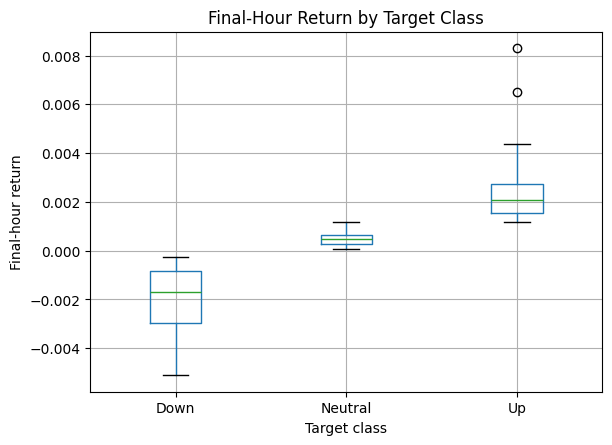

In [49]:
plt.figure(figsize=(8, 5))
features.boxplot(column="target_final_hour_return", by="target_class")
plt.title("Final-Hour Return by Target Class")
plt.suptitle("")
plt.xlabel("Target class")
plt.ylabel("Final-hour return")
plt.show()

## Final-hour movement by day of week

This checks whether certain weekdays show stronger or weaker final-hour movement in the preliminary sample.

Because the sample is small, this should be interpreted carefully. It is useful for exploration, not for drawing firm conclusions.

In [50]:
day_name_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday"
}

features["day_name"] = features["day_of_week"].map(day_name_map)

display(
    features.groupby("day_name")["target_final_hour_return"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
day_name,,,,,,,,
Friday,11.0,-0.000596,0.001751,-0.003601,-0.001852,0.000158,0.000646,0.001539
Monday,11.0,0.000552,0.002962,-0.005115,-0.000311,0.000471,0.000717,0.006492
Thursday,11.0,0.000770,0.001646,-0.003462,0.000396,0.001191,0.001908,0.002527
Tuesday,12.0,0.000805,0.003067,-0.003256,-0.000971,0.000298,0.002300,0.008305
Wednesday,12.0,0.000579,0.001932,-0.002856,-0.000369,0.000655,0.001569,0.004368


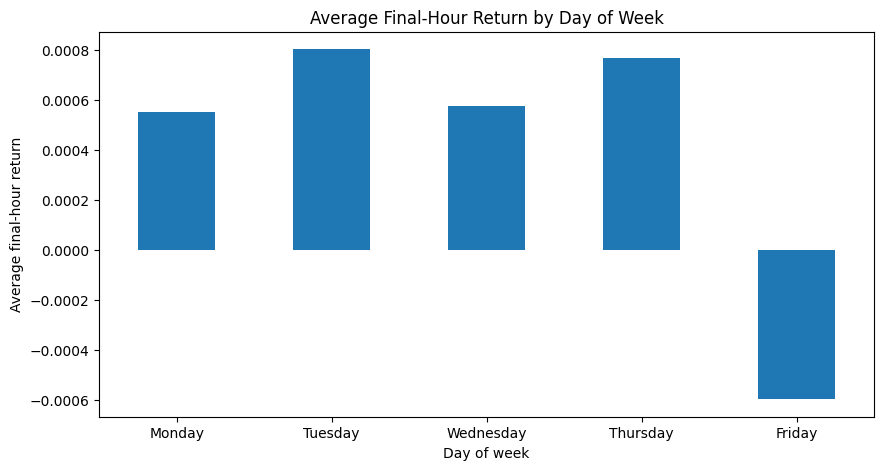

In [51]:
plt.figure(figsize=(10, 5))
features.groupby("day_name")["target_final_hour_return"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
).plot(kind="bar")
plt.title("Average Final-Hour Return by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Average final-hour return")
plt.xticks(rotation=0)
plt.show()

In [52]:
class_by_day = pd.crosstab(features["day_name"], features["target_class"])

class_by_day = class_by_day.reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
)

display(class_by_day)

target_class,Down,Neutral,Up
day_name,,,
Monday,3,6,2
Tuesday,5,2,5
Wednesday,4,4,4
Thursday,2,3,6
Friday,5,4,2


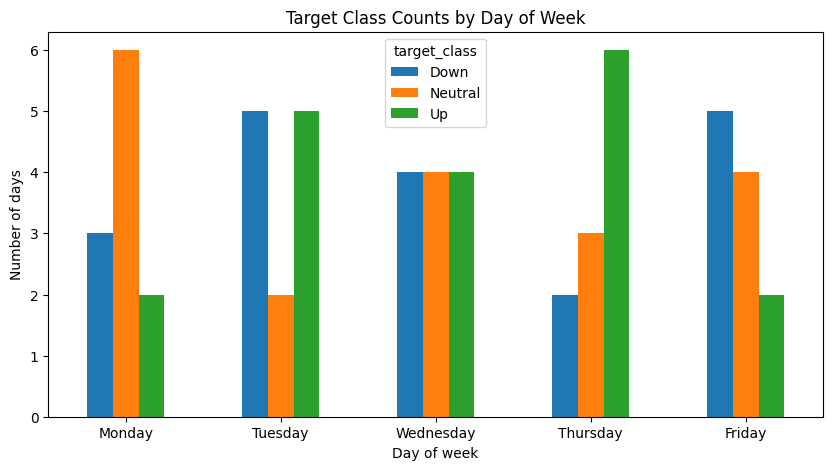

In [53]:
class_by_day.plot(kind="bar", figsize=(10, 5))
plt.title("Target Class Counts by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Number of days")
plt.xticks(rotation=0)
plt.show()

## Selected feature relationships

The following plots compare final-hour return against several important intraday features.

These are not model results. They are only visual checks to see whether any simple relationships appear in the preliminary sample.

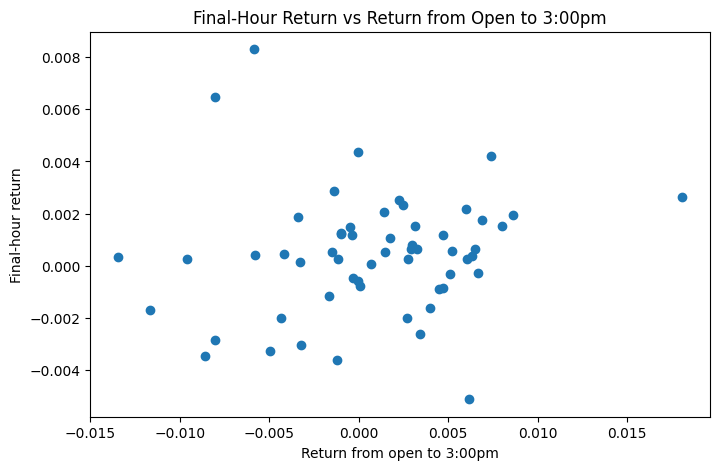

In [54]:
plt.figure(figsize=(8, 5))
plt.scatter(features["ret_open_to_1500"], features["target_final_hour_return"])
plt.title("Final-Hour Return vs Return from Open to 3:00pm")
plt.xlabel("Return from open to 3:00pm")
plt.ylabel("Final-hour return")
plt.show()

Since the points are quite spread out, ret_open_to_1500 may not be enough by itself to predict the final-hour direction. However, it can still be useful when combined with other features like volatility, VIX movement, VWAP distance, and volume.

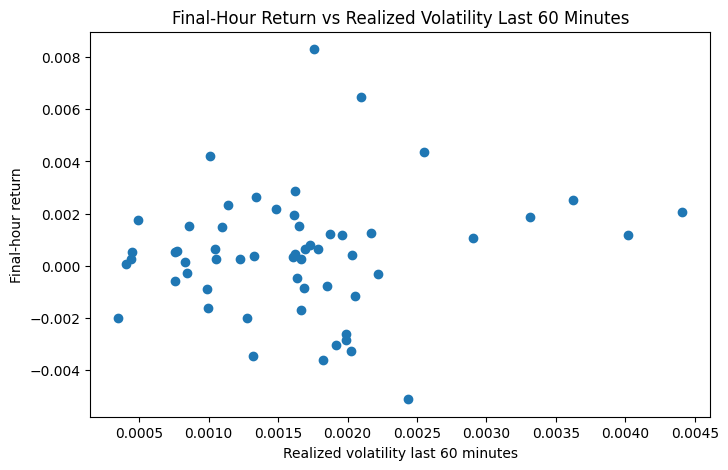

In [55]:
plt.figure(figsize=(8, 5))
plt.scatter(features["realized_vol_60m"], features["target_final_hour_return"])
plt.title("Final-Hour Return vs Realized Volatility Last 60 Minutes")
plt.xlabel("Realized volatility last 60 minutes")
plt.ylabel("Final-hour return")
plt.show()

Sme high volatility days go up, some go down. So this feature is important because it may help model understand market activity and risk before final hour, but alone it is not enough to predict Up or Down.

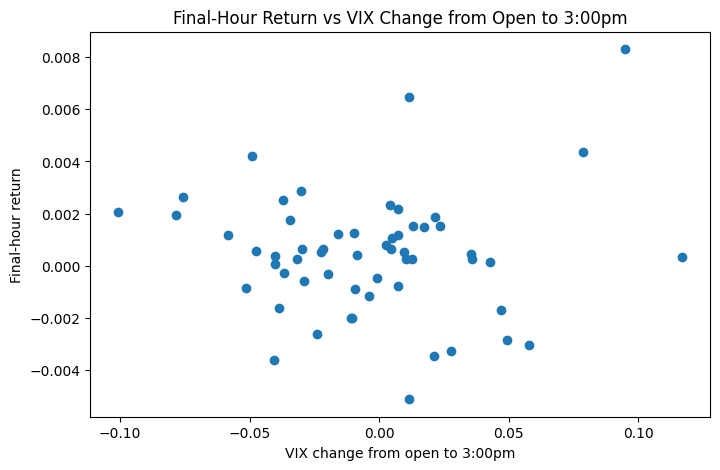

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(features["vix_change_open_to_1500"], features["target_final_hour_return"])
plt.title("Final-Hour Return vs VIX Change from Open to 3:00pm")
plt.xlabel("VIX change from open to 3:00pm")
plt.ylabel("Final-hour return")
plt.show()

Most dots are close to zero, so there is no very strong pattern. When VIX fall before 3:00pm, market sometimes continue up, but not always. When VIX rise before 3:00pm, final-hour return can be up or down. This means VIX change is useful because it show market fear and risk sentiment, but by itself it does not clearly predict final-hour direction.

## Correlation with final-hour return

This table shows the linear correlation between each numeric feature and the final-hour return.

Correlation does not capture nonlinear effects, but it is useful as a simple first check.

In [57]:
numeric_features = features.select_dtypes(include=[np.number])

target_correlations = (
    numeric_features.corr()["target_final_hour_return"]
    .sort_values(ascending=False)
)

display(target_correlations)

target_final_hour_return       1.000000
target                         0.820273
vix_ret_last_60m               0.261382
range_expansion_ratio          0.140222
dist_from_day_low_pct          0.130396
spy_dist_from_vwap_pct         0.128636
dist_from_day_high_pct         0.121011
realized_vol_60m               0.118499
atr_60m                        0.117008
ret_open_to_1500               0.111048
dist_from_open_pct             0.111048
position_in_day_range          0.089729
spy_volume_accel_60m_vs_avg    0.070139
final_close                    0.057442
vix_change_open_to_1500        0.023875
rv_open_to_1500                0.020944
entry_price                    0.015276
atr_open_to_1500               0.011079
range_open_to_1500_pct         0.009115
realized_vol_120m             -0.008753
vix_level_1500                -0.075545
vix_realized_vol_to_1500      -0.108503
spy_volume_last_60m           -0.114432
day_of_week                   -0.141467
spy_cum_volume_to_1500        -0.165169


In [59]:
display(target_correlations.drop("target_final_hour_return").head(10))
display(target_correlations.drop("target_final_hour_return").tail(10))

target                    0.820273
vix_ret_last_60m          0.261382
range_expansion_ratio     0.140222
dist_from_day_low_pct     0.130396
spy_dist_from_vwap_pct    0.128636
dist_from_day_high_pct    0.121011
realized_vol_60m          0.118499
atr_60m                   0.117008
ret_open_to_1500          0.111048
dist_from_open_pct        0.111048
Name: target_final_hour_return, dtype: float64

realized_vol_120m             -0.008753
vix_level_1500                -0.075545
vix_realized_vol_to_1500      -0.108503
spy_volume_last_60m           -0.114432
day_of_week                   -0.141467
spy_cum_volume_to_1500        -0.165169
ret_last_15m                  -0.166215
momentum_accel_60m_vs_prior   -0.212748
ret_last_60m                  -0.238923
ret_last_30m                  -0.281949
Name: target_final_hour_return, dtype: float64

# 8. Prepare dataset for baseline modelling

Before fitting a model, the dataset needs to be split into input features and the prediction target.

The model should only use information that would have been known at the 3:00pm decision point.

Therefore, we exclude:

- `date`, because it is an identifier rather than a market feature
- `entry_datetime`, because it is also an identifier
- `entry_price` and `final_close`, because these are raw price levels rather than stationary predictive features
- `target_final_hour_return`, because this is the actual future return we are trying to predict
- `target_class`, because this is the text version of the target
- `target`, because this is the numeric version of the target label

The target variable for classification will be `target_class`.

In [60]:
# Columns that should not be used as model inputs
exclude_columns = [
    "date",
    "entry_datetime",
    "entry_price",
    "final_close",
    "target_final_hour_return",
    "target_class",
    "target"
]

# Keep all remaining numeric columns as model features
feature_columns = [
    col for col in features.columns
    if col not in exclude_columns and pd.api.types.is_numeric_dtype(features[col])
]

print("Number of feature columns:", len(feature_columns))
display(feature_columns)

Number of feature columns: 25


['ret_open_to_1500',
 'ret_last_15m',
 'ret_last_30m',
 'ret_last_60m',
 'momentum_accel_60m_vs_prior',
 'rv_open_to_1500',
 'realized_vol_60m',
 'realized_vol_120m',
 'atr_open_to_1500',
 'atr_60m',
 'range_open_to_1500_pct',
 'range_expansion_ratio',
 'dist_from_day_high_pct',
 'dist_from_day_low_pct',
 'position_in_day_range',
 'dist_from_open_pct',
 'spy_dist_from_vwap_pct',
 'spy_cum_volume_to_1500',
 'spy_volume_last_60m',
 'spy_volume_accel_60m_vs_avg',
 'vix_level_1500',
 'vix_change_open_to_1500',
 'vix_ret_last_60m',
 'vix_realized_vol_to_1500',
 'day_of_week']

## Create model inputs and target

`X` contains the explanatory variables.

`y` contains the class we want to predict:

- `Down`
- `Neutral`
- `Up`

In [61]:
X = features[feature_columns].copy()
y = features["target_class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (57, 25)
y shape: (57,)


,ret_open_to_1500,ret_last_15m,ret_last_30m,ret_last_60m,momentum_accel_60m_vs_prior,rv_open_to_1500,realized_vol_60m,realized_vol_120m,atr_open_to_1500,atr_60m,...,dist_from_open_pct,spy_dist_from_vwap_pct,spy_cum_volume_to_1500,spy_volume_last_60m,spy_volume_accel_60m_vs_avg,vix_level_1500,vix_change_open_to_1500,vix_ret_last_60m,vix_realized_vol_to_1500,day_of_week
0,-0.003201,-0.000380,0.001334,0.002416,0.003501,0.011554,0.001914,0.003755,18.181818,10.177612,...,-0.003201,-0.003041,64635066,7472329,0.635844,26.959999,0.057670,-0.023896,0.065116,4
1,0.004688,-0.000883,-0.000240,0.001299,0.000772,0.012679,0.001685,0.002414,12.719105,7.270020,...,0.004688,0.000467,58024423,9481040,0.898686,23.770000,-0.051476,-0.012874,0.058074,0
2,-0.000318,0.000336,0.000192,-0.000914,-0.001999,0.007770,0.001637,0.002039,10.044167,7.247681,...,-0.000318,-0.001381,49830735,9019954,0.995565,22.340000,-0.000894,0.004496,0.039803,1
3,-0.008035,-0.002400,-0.004024,-0.004862,-0.004946,0.006386,0.001986,0.003295,11.934149,14.007568,...,-0.008035,-0.005223,48290958,10912819,1.242893,24.059999,0.049280,0.033949,0.050765,2
4,0.001432,0.002927,0.001854,0.001772,0.001673,0.010206,0.004409,0.005391,17.042791,15.922485,...,0.001432,0.001494,71756487,10918728,0.836900,24.490000,-0.100624,-0.019616,0.073078,3


0    Down
1    Down
2    Down
3    Down
4      Up
Name: target_class, dtype: object

In [62]:
display(X.isna().sum())

ret_open_to_1500               0
ret_last_15m                   0
ret_last_30m                   0
ret_last_60m                   0
momentum_accel_60m_vs_prior    0
rv_open_to_1500                0
realized_vol_60m               0
realized_vol_120m              0
atr_open_to_1500               0
atr_60m                        0
range_open_to_1500_pct         0
range_expansion_ratio          0
dist_from_day_high_pct         0
dist_from_day_low_pct          0
position_in_day_range          0
dist_from_open_pct             0
spy_dist_from_vwap_pct         0
spy_cum_volume_to_1500         0
spy_volume_last_60m            0
spy_volume_accel_60m_vs_avg    0
vix_level_1500                 0
vix_change_open_to_1500        0
vix_ret_last_60m               0
vix_realized_vol_to_1500       0
day_of_week                    0
dtype: int64

In [63]:
# Drop rows with missing values if any exist
model_data = pd.concat([X, y], axis=1).dropna()

X = model_data[feature_columns].copy()
y = model_data["target_class"].copy()

print("X shape after dropping missing rows:", X.shape)
print("y shape after dropping missing rows:", y.shape)

X shape after dropping missing rows: (57, 25)
y shape after dropping missing rows: (57,)


## Chronological train/test split

Because this is financial time-series data, the train/test split should preserve time order.

A random split would allow future observations to influence the training process, which would not reflect a realistic trading setup.

Here, the first 70% of observations are used for training and the final 30% are used for testing.

In [64]:
split_index = int(len(X) * 0.70)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 39
Testing observations: 18


## Check train/test class balance

This checks whether all three classes are represented in both the training and testing sets.

This is especially important because the sample is small.

In [65]:
print("Training class distribution:")
display(y_train.value_counts())

print("Testing class distribution:")
display(y_test.value_counts())

Training class distribution:


target_class
Neutral    16
Up         12
Down       11
Name: count, dtype: int64

Testing class distribution:


target_class
Down       8
Up         7
Neutral    3
Name: count, dtype: int64

In [66]:
class_balance = pd.DataFrame({
    "train": y_train.value_counts(),
    "test": y_test.value_counts()
}).fillna(0)

display(class_balance)

,train,test
target_class,,
Down,11,8
Neutral,16,3
Up,12,7


## Feature summary

This table shows the selected modelling features and their basic descriptive statistics.

It helps confirm that the feature values are on different scales, which is why scaling will be useful for a logistic regression baseline.


In [67]:
display(X_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
ret_open_to_1500,39.0,5.019372e-04,6.307795e-03,-1.343365e-02,-3.326870e-03,6.924757e-04,4.712216e-03,1.808041e-02
ret_last_15m,39.0,-2.754365e-05,1.123076e-03,-2.399638e-03,-6.381797e-04,-1.511983e-05,4.298722e-04,2.926949e-03
ret_last_30m,39.0,2.512475e-05,1.466446e-03,-4.023850e-03,-3.408698e-04,1.920010e-04,1.341608e-03,2.359128e-03
ret_last_60m,39.0,-2.564473e-04,2.201844e-03,-5.239792e-03,-1.304273e-03,5.191909e-05,1.302652e-03,3.484385e-03
momentum_accel_60m_vs_prior,39.0,-1.402500e-04,2.864104e-03,-5.148957e-03,-2.338667e-03,-2.924061e-04,1.748663e-03,6.458598e-03
rv_open_to_1500,39.0,8.198622e-03,4.578129e-03,2.220041e-03,5.120027e-03,7.057386e-03,9.213052e-03,2.413019e-02
realized_vol_60m,39.0,1.731584e-03,8.463994e-04,4.023857e-04,1.182345e-03,1.662058e-03,1.987007e-03,4.408819e-03
realized_vol_120m,39.0,2.734396e-03,1.431241e-03,6.051566e-04,1.851887e-03,2.587917e-03,3.266764e-03,8.283804e-03
atr_open_to_1500,39.0,1.254177e+01,3.684348e+00,6.765425e+00,9.647061e+00,1.223548e+01,1.486367e+01,2.180549e+01
atr_60m,39.0,9.575521e+00,3.600759e+00,3.532349e+00,6.786255e+00,9.644897e+00,1.219006e+01,1.649512e+01


### Feature Summary and Modelling Interpretation

**Note:** Most return variables are in decimal form. For example, `0.001` means `0.1%`, not `0.001%`. Also, the count is `39`, meaning the summary is based on 39 trading days.

| Feature                       | What the output shows                                                         | Meaning for modelling                                                                                  | Real-life market meaning                                                                  |
| ----------------------------- | ----------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------- |
| `ret_open_to_1500`            | • Mean around `0.05%`  <br> • Range from about `-1.34%` to `+1.81%`           | • Shows full-day direction before 3pm <br> • Useful for trend or reversal signal                       | • Shows whether SPX was strong or weak before final hour                                  |
| `ret_last_15m`                | • Very small average move <br> • Max around `+0.29%`, min around `-0.24%`     | • Captures very recent momentum <br> • Can help detect short-term pressure                             | • Shows last 15-minute buying or selling before entry                                     |
| `ret_last_30m`                | • Average close to zero <br> • Range from about `-0.40%` to `+0.24%`          | • Useful for short-term continuation or reversal                                                       | • Shows whether market was gaining or losing strength before 3pm                          |
| `ret_last_60m`                | • Mean slightly negative <br> • Range from about `-0.52%` to `+0.35%`         | • Important recent momentum feature <br> • Negative correlation with target may suggest reversal       | • Shows how SPX moved in the hour before final-hour trade                                 |
| `momentum_accel_60m_vs_prior` | • Measures change in momentum <br> • Range from about `-0.51%` to `+0.65%`    | • Helps model detect acceleration or fading momentum                                                   | • Shows whether the latest hour is stronger or weaker than the previous hour              |
| `rv_open_to_1500`             | • Mean around `0.82%` <br> • Max around `2.41%`                               | • Captures total volatility before 3pm <br> • Useful for risk regime                                   | • Higher value means market was more unstable during the day                              |
| `realized_vol_60m`            | • Mean around `0.17%` <br> • Max around `0.44%`                               | • Shows recent volatility before final hour <br> • May help predict size of move, not always direction | • High value means market active before 3pm                                               |
| `realized_vol_120m`           | • Mean around `0.27%` <br> • Max around `0.83%`                               | • Gives wider volatility context than 60-minute volatility                                             | • Shows if market was calm or volatile over last two hours                                |
| `atr_open_to_1500`            | • Mean about `12.54` SPX points <br> • Range from `6.77` to `21.81` points    | • Measures average intraday price range <br> • Useful for market activity level                        | • Shows average SPX movement per bar before 3pm                                           |
| `atr_60m`                     | • Mean about `9.58` SPX points <br> • Range from `3.53` to `16.50` points     | • Measures recent trading range <br> • Can show if volatility is expanding before entry                | • Higher ATR means bigger short-term SPX swings                                           |
| `range_open_to_1500_pct`      | • Mean around `0.95%` <br> • Max around `1.96%`                               | • Shows total intraday range before 3pm                                                                | • Wider range means market had larger movement during day                                 |
| `range_expansion_ratio`       | • Mean around `0.77` <br> • Max `1.58`                                        | • Shows if recent range is bigger than average day range                                               | • Above 1 means final pre-entry period is more volatile than normal                       |
| `dist_from_day_high_pct`      | • Mean around `-0.47%` <br> • Always negative because price is below day high | • Shows how close price is to breakout high                                                            | • Near zero means SPX is close to day high, possible strength                             |
| `dist_from_day_low_pct`       | • Mean around `0.48%` <br> • Max around `1.81%`                               | • Shows how far price is from day low                                                                  | • Bigger value means SPX moved away from low, possible recovery                           |
| `position_in_day_range`       | • Mean around `0.52` <br> • Range from near `0` to near `1`                   | • Useful for classifying price position inside day range                                               | • Near 1 means price near day high; near 0 means price near day low                       |
| `dist_from_open_pct`          | • Same as `ret_open_to_1500`                                                  | • Duplicate-style feature <br> • May remove later to avoid repetition                                  | • Shows distance from market open price                                                   |
| `spy_dist_from_vwap_pct`      | • Mean near zero <br> • Range from about `-0.62%` to `+0.78%`                 | • Useful because VWAP shows fair intraday price level                                                  | • Above VWAP shows buying pressure; below VWAP shows selling pressure                     |
| `spy_cum_volume_to_1500`      | • Mean around `47.5 million` shares <br> • Max around `98 million`            | • Shows level of market participation                                                                  | • High volume means more active and liquid trading day                                    |
| `spy_volume_last_60m`         | • Mean around `7.37 million` shares <br> • Max around `19.65 million`         | • Captures recent volume before final hour                                                             | • Higher value means more activity before entry                                           |
| `spy_volume_accel_60m_vs_avg` | • Mean around `0.85` <br> • Max around `1.31`                                 | • Shows whether recent volume is above or below daily average                                          | • Above 1 means volume is accelerating before final hour                                  |
| `vix_level_1500`              | • Mean around `21.86` <br> • Range from `16.87` to `31.13`                    | • Measures fear/risk level at 3pm                                                                      | • Higher VIX means more uncertainty and option premium                                    |
| `vix_change_open_to_1500`     | • Mean around `0.23%` <br> • Range from `-10.06%` to `+11.69%`                | • Shows change in market fear during day                                                               | • Rising VIX often means fear increasing; falling VIX often means risk appetite improving |
| `vix_ret_last_60m`            | • Mean around `0.10%` <br> • Range from `-3.09%` to `+6.27%`                  | • Captures recent change in fear before final hour                                                     | • Rising VIX in last hour before 3pm may signal stress                                    |
| `vix_realized_vol_to_1500`    | • Mean around `4.60%` <br> • Max around `10.83%`                              | • Shows how unstable VIX was before 3pm                                                                | • High value means fear index was moving sharply                                          |
| `day_of_week`                 | • Values from `0` to `4` <br> • Monday = 0, Friday = 4                        | • Captures possible weekday pattern                                                                    | • Some days may behave differently because of expiry, news, or weekly flows               |

Overall, the variables are usable even if some values look small. They are small because they are mostly intraday decimal returns. For modelling, the important point is not the size of the number, but whether the feature has variation and helps explain final-hour movement. Linear models may need scaling, but tree-based models can usually handle different feature sizes better.


# 9. Baseline logistic regression model

This section fits a simple multinomial logistic regression model.

Logistic regression is useful as a baseline because it is relatively interpretable and provides a simple benchmark before using more complex models such as Random Forest, XGBoost, or LSTM models.

Because the input features are on different scales, the model is placed inside a pipeline with `StandardScaler`.

The model is trained on the earlier part of the sample and tested on the later part of the sample.

In [68]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## Generate test-set predictions

The model is now used to predict the target class for the test period.

These predictions are compared against the actual final-hour movement classes.

In [69]:
y_pred = baseline_model.predict(X_test)

predictions = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

display(predictions.head())

,actual,predicted
39,Up,Up
40,Neutral,Up
41,Up,Up
42,Down,Up
43,Down,Neutral


## Classification report

The classification report shows model performance for each class.

The main metrics are:

- `precision`: when the model predicts a class, how often it is correct
- `recall`: out of all actual observations in a class, how many the model correctly finds
- `f1-score`: balance between precision and recall
- `support`: number of observations in each class

Because this is an early baseline model using a small sample, the results should be interpreted cautiously.

In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Down       0.00      0.00      0.00         8
     Neutral       0.25      0.67      0.36         3
          Up       0.38      0.43      0.40         7

    accuracy                           0.28        18
   macro avg       0.21      0.37      0.25        18
weighted avg       0.19      0.28      0.22        18



## Confusion matrix

The confusion matrix shows where the model is making correct and incorrect predictions.

Rows represent the actual class, while columns represent the predicted class.

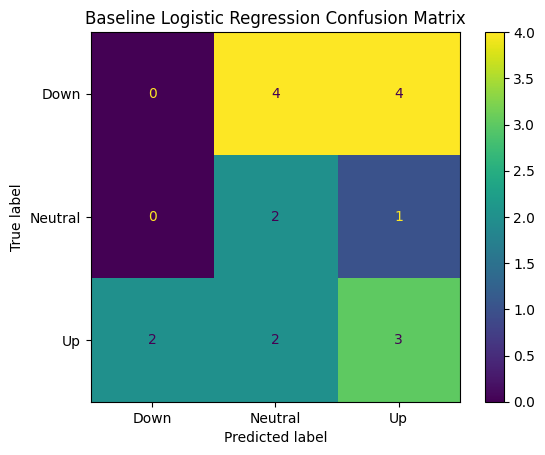

In [71]:
labels = ["Down", "Neutral", "Up"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

## Review predictions by date

This table allows us to inspect the model predictions alongside the actual final-hour returns.

This helps identify whether the model is missing large moves or mainly struggling around borderline cases.

In [72]:
test_results = features.iloc[split_index:].copy()

test_results = test_results.loc[X_test.index].copy()
test_results["predicted_class"] = y_pred
test_results["correct_prediction"] = test_results["target_class"] == test_results["predicted_class"]

display(test_results[[
    "date",
    "target_final_hour_return",
    "target_class",
    "predicted_class",
    "correct_prediction"
]])

,date,target_final_hour_return,target_class,predicted_class,correct_prediction
39,2026-05-08,0.001539,Up,Up,True
40,2026-05-11,0.000788,Neutral,Up,False
41,2026-05-12,0.002851,Up,Up,True
42,2026-05-13,-0.000302,Down,Up,False
43,2026-05-14,-0.000267,Down,Neutral,False
44,2026-05-15,-0.003601,Down,Up,False
45,2026-05-18,0.006492,Up,Neutral,False
46,2026-05-19,-0.001164,Down,Up,False
47,2026-05-20,0.001741,Up,Neutral,False
48,2026-05-21,0.002527,Up,Up,True


## Baseline accuracy

Accuracy measures the percentage of test observations where the predicted class matches the actual class.

Because there are three classes, a simple naive benchmark would be around one-third accuracy if classes are balanced.

In [73]:
baseline_accuracy = (test_results["correct_prediction"]).mean()

print("Baseline logistic regression accuracy:", baseline_accuracy)

Baseline logistic regression accuracy: 0.2777777777777778


Even though the accuracy of 27% is very low for most models, we would expect a baseline model that simply guesses one outcome over another to have an accuracy rate of about 33%. Therefore, the baseline model did not demonstrate significant predictive power. 

## Logistic regression coefficients

Logistic regression produces coefficients for each feature and each target class.

These coefficients are not the same as feature importance in a tree-based model, but they give an initial indication of which variables influence the model's class predictions.

Because the model uses scaled features, the coefficients are more comparable across variables.

In [75]:
model = baseline_model.named_steps["model"]

coef_df = pd.DataFrame(
    model.coef_,
    columns=feature_columns,
    index=model.classes_
)

display(coef_df)

,ret_open_to_1500,ret_last_15m,ret_last_30m,ret_last_60m,momentum_accel_60m_vs_prior,rv_open_to_1500,realized_vol_60m,realized_vol_120m,atr_open_to_1500,atr_60m,...,dist_from_open_pct,spy_dist_from_vwap_pct,spy_cum_volume_to_1500,spy_volume_last_60m,spy_volume_accel_60m_vs_avg,vix_level_1500,vix_change_open_to_1500,vix_ret_last_60m,vix_realized_vol_to_1500,day_of_week
Down,0.011673,-0.265108,0.186907,0.851948,-0.122057,0.328650,-0.216835,0.123418,-0.191183,-0.066532,...,0.011673,-0.237349,0.118442,0.208362,0.135442,0.042876,-0.10675,-0.013115,-0.007850,-0.088978
Neutral,-0.011906,0.470434,-0.039097,-0.087213,0.320029,-1.066095,-0.378856,-0.426187,0.468991,0.092156,...,-0.011906,-0.147370,0.290625,0.115557,0.064964,-0.132422,0.01644,0.448314,-0.048238,0.015330
Up,0.000234,-0.205327,-0.147810,-0.764735,-0.197971,0.737445,0.595691,0.302769,-0.277808,-0.025624,...,0.000234,0.384719,-0.409067,-0.323920,-0.200407,0.089546,0.09031,-0.435199,0.056088,0.073647


In [76]:
# Show the largest positive coefficients for each class
for class_name in coef_df.index:
    print(f"\nTop positive coefficients for class: {class_name}")
    display(coef_df.loc[class_name].sort_values(ascending=False).head(10))

    print(f"Top negative coefficients for class: {class_name}")
    display(coef_df.loc[class_name].sort_values(ascending=True).head(10))


Top positive coefficients for class: Down


ret_last_60m                   0.851948
rv_open_to_1500                0.328650
spy_volume_last_60m            0.208362
ret_last_30m                   0.186907
spy_volume_accel_60m_vs_avg    0.135442
realized_vol_120m              0.123418
spy_cum_volume_to_1500         0.118442
vix_level_1500                 0.042876
ret_open_to_1500               0.011673
dist_from_open_pct             0.011673
Name: Down, dtype: float64

Top negative coefficients for class: Down


position_in_day_range         -0.601225
dist_from_day_low_pct         -0.366672
dist_from_day_high_pct        -0.299263
ret_last_15m                  -0.265108
spy_dist_from_vwap_pct        -0.237349
realized_vol_60m              -0.216835
atr_open_to_1500              -0.191183
momentum_accel_60m_vs_prior   -0.122057
vix_change_open_to_1500       -0.106750
day_of_week                   -0.088978
Name: Down, dtype: float64


Top positive coefficients for class: Neutral


...

rv_open_to_1500            -1.066095
realized_vol_120m          -0.426187
realized_vol_60m           -0.378856
dist_from_day_low_pct      -0.195907
spy_dist_from_vwap_pct     -0.147370
vix_level_1500             -0.132422
dist_from_day_high_pct     -0.128353
ret_last_60m               -0.087213
range_open_to_1500_pct     -0.066995
vix_realized_vol_to_1500   -0.048238
Name: Neutral, dtype: float64


Top positive coefficients for class: Up


rv_open_to_1500            0.737445
realized_vol_60m           0.595691
dist_from_day_low_pct      0.562579
position_in_day_range      0.458342
dist_from_day_high_pct     0.427615
spy_dist_from_vwap_pct     0.384719
realized_vol_120m          0.302769
range_open_to_1500_pct     0.144462
vix_change_open_to_1500    0.090310
vix_level_1500             0.089546
Name: Up, dtype: float64

Top negative coefficients for class: Up


ret_last_60m                  -0.764735
vix_ret_last_60m              -0.435199
spy_cum_volume_to_1500        -0.409067
spy_volume_last_60m           -0.323920
atr_open_to_1500              -0.277808
ret_last_15m                  -0.205327
spy_volume_accel_60m_vs_avg   -0.200407
momentum_accel_60m_vs_prior   -0.197971
ret_last_30m                  -0.147810
atr_60m                       -0.025624
Name: Up, dtype: float64

- |model seems to use volatility features strongly.
- high realized volatility reduces Neutral prediction and supports directional movement.
- price position features help the model separate Up from Down.
- VWAP distance is useful because price above VWAP can show buying pressure.
- some momentum features show possible reversal behaviour.
- the baseline accuracy is low, so these patterns should not be treated as strong trading signals yet.